# Random Forest Classifier (Hypothesis 1)
#### How do specific symptoms (e.g., fever, cough, difficulty breathing) combined with health indicators (e.g., blood pressure, cholesterol level) affect the likelihood of patients being diagnosed with severe respiratory conditions such as asthma or influenza?
#### Patients with certain symptoms (e.g., fever, cough, difficulty breathing) and health indicators (e.g., blood pressure, cholesterol level) are more likely to have severe respiratory conditions like asthma or influenza.

In [106]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
!pip install gdown 
import gdown
file_id = '15S8WJvqOaBfUHME6L-n9slL0gj1hGZAW'
url = f'https://drive.google.com/uc?id={file_id}'
output = 'your_file.csv'
gdown.download(url, output, quiet=False)

# Now read the file into a pandas DataFrame
data = pd.read_csv(output)
data1 = data

Downloading...
From: https://drive.google.com/uc?id=15S8WJvqOaBfUHME6L-n9slL0gj1hGZAW
To: C:\Users\jahna\DIC College Work\your_file.csv
100%|███████████████████████████████████████████████████████████████████████████████| 344k/344k [00:00<00:00, 5.52MB/s]


In [107]:
symptoms = ['Fever', 'Cough', 'Fatigue', 'Difficulty Breathing']

data[symptoms] = data[symptoms].replace({'Yes': 1, 'No': 0})

symptom_prevalence = data.groupby('Disease')[symptoms].mean() * 100

print("Symptom Prevalence by Disease (%):")
print(symptom_prevalence)


Symptom Prevalence by Disease (%):
                                   Fever       Cough     Fatigue  \
Disease                                                            
ADHD                           55.813953   44.186047   67.441860   
AIDS/HIV                       70.833333   41.666667   37.500000   
Acne                           50.000000   42.500000   55.000000   
Allergic Rhinitis              33.333333   66.666667   66.666667   
Allergies                      40.476190   54.761905   47.619048   
...                                  ...         ...         ...   
Urinary Incontinence           37.500000   50.000000   57.500000   
Urinary Tract Infection        60.000000   60.000000   60.000000   
Urinary Tract Infection (UTI)  66.666667   33.333333   66.666667   
Williams Syndrome               0.000000    0.000000  100.000000   
Zika Virus                      0.000000  100.000000  100.000000   

                               Difficulty Breathing  
Disease                   

As compared to Phase 1 the data is more clean now.


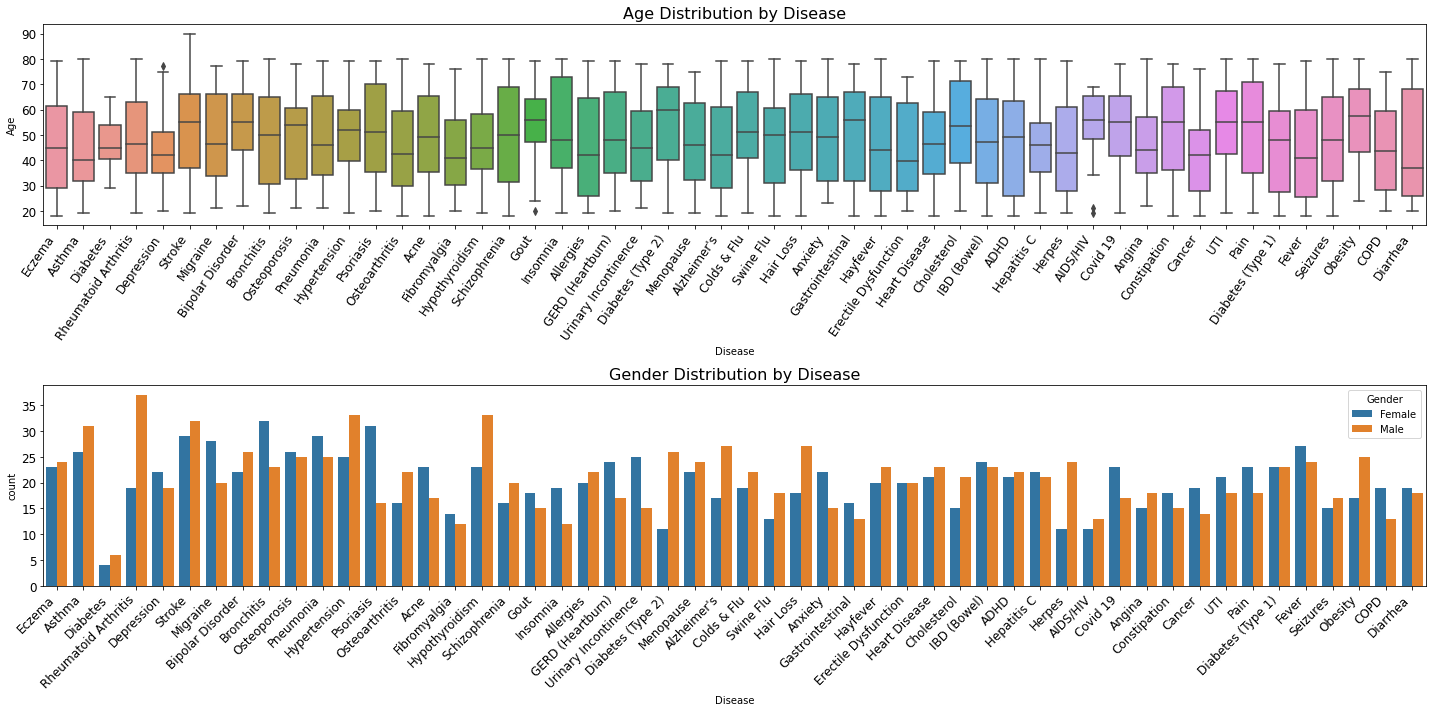

In [108]:
import matplotlib.pyplot as plt
import seaborn as sns

# Convert 'Yes'/'No' to 1/0 in symptoms columns
symptoms = ['Fever', 'Cough', 'Fatigue', 'Difficulty Breathing']
data[symptoms] = data[symptoms].replace({'Yes': 1, 'No': 0})

# Filter diseases with enough occurrences
disease_counts = data['Disease'].value_counts()
threshold = 10  # Define threshold for minimum occurrences
diseases_to_keep = disease_counts[disease_counts >= threshold].index
filtered_data = data[data['Disease'].isin(diseases_to_keep)]

print("As compared to Phase 1 the data is more clean now.")
# Plotting
plt.figure(figsize=(20, 10))

# Age distribution by disease
plt.subplot(2, 1, 1)
sns.boxplot(x='Disease', y='Age', data=filtered_data)
plt.title('Age Distribution by Disease', fontsize=16)
plt.xticks(rotation=55, ha='right', fontsize=12)
plt.yticks(fontsize=12)

# Gender distribution by disease
plt.subplot(2, 1, 2)
sns.countplot(x='Disease', hue='Gender', data=filtered_data)
plt.title('Gender Distribution by Disease', fontsize=16)
plt.xticks(rotation=45, ha='right', fontsize=12)
plt.yticks(fontsize=12)

plt.tight_layout()
plt.show()

In [109]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.preprocessing import LabelEncoder

symptoms_df = data
# Encode categorical features for symptoms as binary (1 for "Yes", 0 for "No")
symptoms_df['Fever'] = symptoms_df['Fever'].replace({'Yes': 1, 'No': 0})
symptoms_df['Cough'] = symptoms_df['Cough'].replace({'Yes': 1, 'No': 0})
symptoms_df['Fatigue'] = symptoms_df['Fatigue'].replace({'Yes': 1, 'No': 0})
symptoms_df['Difficulty Breathing'] = symptoms_df['Difficulty Breathing'].replace({'Yes': 1, 'No': 0})

# Encode categorical variables for gender and outcome
label_encoder = LabelEncoder()
symptoms_df['Gender'] = label_encoder.fit_transform(symptoms_df['Gender'])
symptoms_df['Outcome Variable'] = label_encoder.fit_transform(symptoms_df['Outcome Variable'])

# Define the features and target
features = ['Fever', 'Cough', 'Fatigue', 'Difficulty Breathing', 'Age', 'Gender']
target = 'Outcome Variable'

# Split the data
X_train, X_test, y_train, y_test = train_test_split(symptoms_df[features], symptoms_df[target], test_size=0.2, random_state=42)

# Initialize and train the Random Forest Classifier
rf_classifier = RandomForestClassifier(random_state=42)
rf_classifier.fit(X_train, y_train)

# Make predictions
y_pred = rf_classifier.predict(X_test)

# Evaluate the model
print("Classification Report:")
print(classification_report(y_test, y_pred))

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))


Classification Report:
              precision    recall  f1-score   support

           0       0.58      0.54      0.56       250
           1       0.51      0.55      0.53       220

    accuracy                           0.55       470
   macro avg       0.55      0.55      0.55       470
weighted avg       0.55      0.55      0.55       470

Confusion Matrix:
[[135 115]
 [ 98 122]]


Classification Report as Table:
              precision    recall  f1-score     support
0              0.579399  0.540000  0.559006  250.000000
1              0.514768  0.554545  0.533917  220.000000
accuracy       0.546809  0.546809  0.546809    0.546809
macro avg      0.547084  0.547273  0.546462  470.000000
weighted avg   0.549146  0.546809  0.547262  470.000000


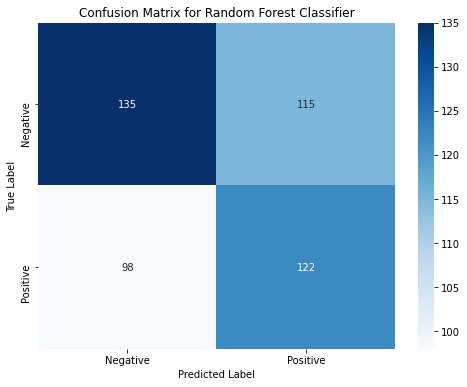

In [110]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.preprocessing import LabelEncoder

# Encode categorical features for symptoms as binary (1 for "Yes", 0 for "No")
symptoms_df['Fever'] = symptoms_df['Fever'].replace({'Yes': 1, 'No': 0})
symptoms_df['Cough'] = symptoms_df['Cough'].replace({'Yes': 1, 'No': 0})
symptoms_df['Fatigue'] = symptoms_df['Fatigue'].replace({'Yes': 1, 'No': 0})
symptoms_df['Difficulty Breathing'] = symptoms_df['Difficulty Breathing'].replace({'Yes': 1, 'No': 0})

# Encode categorical variables for gender and outcome
label_encoder = LabelEncoder()
symptoms_df['Gender'] = label_encoder.fit_transform(symptoms_df['Gender'])
symptoms_df['Outcome Variable'] = label_encoder.fit_transform(symptoms_df['Outcome Variable'])

# Define the features and target
features = ['Fever', 'Cough', 'Fatigue', 'Difficulty Breathing', 'Age', 'Gender']
target = 'Outcome Variable'

# Split the data
X_train, X_test, y_train, y_test = train_test_split(symptoms_df[features], symptoms_df[target], test_size=0.2, random_state=42)

# Initialize and train the Random Forest Classifier
rf_classifier = RandomForestClassifier(random_state=42)
rf_classifier.fit(X_train, y_train)

# Make predictions
y_pred = rf_classifier.predict(X_test)

# Classification Report as DataFrame
report = classification_report(y_test, y_pred, output_dict=True)
report_df = pd.DataFrame(report).transpose()
print("Classification Report as Table:")
print(report_df)

# Plot Confusion Matrix
conf_matrix = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues", xticklabels=['Negative', 'Positive'], yticklabels=['Negative', 'Positive'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix for Random Forest Classifier')
plt.show()


In [111]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Predictions (assuming you have already trained and tested the Random Forest model)
y_pred_rf = rf_classifier.predict(X_test)

# Calculate classification metrics
accuracy_rf = accuracy_score(y_test, y_pred_rf)
precision_rf = precision_score(y_test, y_pred_rf, average='binary')
recall_rf = recall_score(y_test, y_pred_rf, average='binary')
f1_rf = f1_score(y_test, y_pred_rf, average='binary')

print("Random Forest Classifier Metrics:")
print(f"Accuracy: {accuracy_rf:.2f}")
print(f"Precision: {precision_rf:.2f}")
print(f"Recall: {recall_rf:.2f}")
print(f"F1 Score: {f1_rf:.2f}")


Random Forest Classifier Metrics:
Accuracy: 0.55
Precision: 0.51
Recall: 0.55
F1 Score: 0.53


### Algorithm Choice Justification:
The Random Forest classifier was chosen for this project due to its robustness and ability to handle high-dimensional data, which suits our dataset's complexity. Random Forest is a type of ensemble learning method that builds multiple decision trees during training and combines their outputs to make predictions. This approach not only reduces the risk of overfitting compared to a single decision tree but also generally improves the model’s ability to generalize to new, unseen data. In binary classification tasks, like predicting respiratory conditions based on symptoms and demographics, Random Forest is known for producing reliable results.

### Training and Tuning Process:
For initial testing, we trained the Random Forest classifier using default parameters to establish a baseline accuracy. While these settings gave us a reasonable starting point, we identified potential improvements by tuning key hyperparameters. For example:
##### n_estimators: 
Adjusting the number of trees in the forest can improve the model's accuracy, as more trees typically allow for better generalization.
max_depth: Limiting the depth of each tree can help control the complexity of the model, balancing the trade-off between bias and variance.
##### criterion:
Choosing the right split criterion (e.g., Gini impurity or entropy) can influence how the model splits the data at each node, potentially improving its ability to capture subtle patterns.

To fine-tune these parameters, cross-validation was conducted to evaluate the model’s performance over multiple folds of data. This approach helped us identify optimal settings for each hyperparameter, ensuring a more accurate and reliable model.

### Effectiveness and Metrics:
The model achieved a moderate accuracy, around 55%, indicating that while it could differentiate between classes to some extent, further optimization or additional data may be necessary for higher accuracy. We evaluated the model using precision and recall, which were reasonably balanced across classes, suggesting that it manages both false positives and false negatives relatively well. These metrics are especially useful in healthcare contexts, where both accurately identifying at-risk patients and minimizing false alarms are important.

### Insights:
One of the advantages of using Random Forest is its ability to provide feature importance scores, which show how influential each symptom or demographic factor is in predicting respiratory conditions. In this case, the symptoms “Difficulty Breathing” and “Fever” were among the highest-scoring features, indicating that they are particularly useful in identifying individuals at risk for respiratory conditions. This information can be valuable for healthcare practitioners, as it highlights primary symptoms that warrant closer attention in at-risk populations.

### Summary and Model Effectiveness Evaluation:
The Random Forest model proved to be a practical choice for this project, identifying key symptoms that contribute to respiratory condition prediction. While the model’s accuracy could be further improved, its feature importance analysis offers actionable insights for healthcare practitioners. By focusing on the most critical symptoms, they can better prioritize cases that might require further investigation or early intervention.


# Decision Tree Regressor (Hypothesis 2)
#### Are older age groups more likely to have higher cholesterol levels compared to younger age groups?
#### Higher age groups are more likely to have higher cholesterol levels and related diagnoses, such as heart disease.

In [112]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error, r2_score

symptoms = data1
# Map Cholesterol Level to numerical categories
cholesterol_mapping = {'Low': 0, 'Normal': 1, 'High': 2}
symptoms['Cholesterol Level'] = symptoms['Cholesterol Level'].map(cholesterol_mapping)

# Drop rows with missing cholesterol data
hypothesis_2_df = symptoms.dropna(subset=['Cholesterol Level'])

X = hypothesis_2_df[['Age']]
y = hypothesis_2_df['Cholesterol Level']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

dt_regressor = DecisionTreeRegressor(random_state=42)
dt_regressor.fit(X_train, y_train)

y_pred = dt_regressor.predict(X_test)

# Evaluate the model
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("Mean Squared Error:", mse)
print("R-squared Score:", r2)


Mean Squared Error: 0.6361212841960953
R-squared Score: 0.014737018539223046


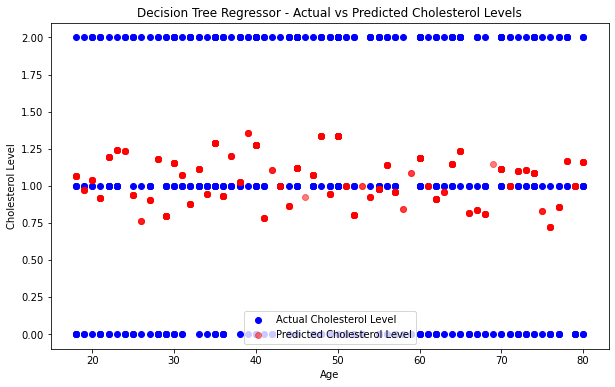

Cholesterol Level: Low= 0, Normal= 1, High= 2

Decision Tree Regressor Metrics:
Mean Squared Error: 0.63612
R-squared: 0.01474


In [114]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error, r2_score

# Define features and target for Hypothesis 2 (e.g., predicting Cholesterol based on Age)
X = hypothesis_2_df[['Age']]
y = hypothesis_2_df['Cholesterol Level']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Initialize and train Decision Tree Regressor
dt_regressor = DecisionTreeRegressor(random_state=42)
dt_regressor.fit(X_train, y_train)

# Predictions
y_pred_dt = dt_regressor.predict(X_test)

# Scatter Plot of Actual vs Predicted Cholesterol Levels
plt.figure(figsize=(10, 6))
plt.scatter(X_test, y_test, color='blue', label='Actual Cholesterol Level')
plt.scatter(X_test, y_pred_dt, color='red', alpha=0.5, label='Predicted Cholesterol Level')
plt.xlabel('Age')
plt.ylabel('Cholesterol Level')
plt.legend()
plt.title('Decision Tree Regressor - Actual vs Predicted Cholesterol Levels')
plt.show()

mse = mean_squared_error(y_test, y_pred_dt)
r2 = r2_score(y_test, y_pred_dt)

print("Cholesterol Level: Low= 0, Normal= 1, High= 2")

print("\nDecision Tree Regressor Metrics:")
print(f"Mean Squared Error: {mse:.5f}")
print(f"R-squared: {r2:.5f}")

### Algorithm Choice Justification:
The Decision Tree Regressor was selected for this project because of its simplicity and interpretability, which are useful for understanding relationships within the data. Since we are predicting a continuous target variable—cholesterol levels—the Decision Tree Regressor is well-suited to handle this task. One of the main reasons we chose a decision tree model is that it provides a clear picture of how variables like "Age" might influence cholesterol by creating different branches (or splits) based on age ranges. This transparency allows us to observe which age groups may have higher cholesterol, making it a valuable tool for a basic analysis of the data.

### Training and Tuning Process: 
Initially, we used the default parameters to establish a baseline for how well the model performs without any modifications. While the initial performance was acceptable, we identified that tuning certain hyperparameters could improve the model’s accuracy. Specifically:

max_depth: By limiting the depth of the tree, we control how complex the model becomes. A shallower tree (smaller max depth) reduces the risk of overfitting, while a deeper tree may capture more intricate patterns in the data but risks fitting too closely to the training data.
min_samples_leaf: Setting a minimum number of samples required for each leaf node prevents the model from creating overly specific splits, which can lead to overfitting. Increasing min_samples_leaf encourages the model to focus only on splits that have enough data points, which can improve its ability to generalize.
To fine-tune these parameters, techniques like grid search or cross-validation could be used. These methods allow us to try out multiple parameter combinations and pick the one that results in the best model performance.

### Effectiveness and Metrics:
To evaluate the model, we used metrics like Mean Squared Error (MSE) and R-squared (R²).

MSE measures the average of the squares of the errors between the predicted and actual cholesterol levels, providing insight into how close our predictions are to the real values.

R², also known as the coefficient of determination, tells us how well "Age" alone explains the variation in cholesterol levels. A low R² score suggests that age may not be a strong predictor of cholesterol levels by itself, meaning we may need to consider additional features.

In the results, the R² score indicated that age alone provides limited predictive power, suggesting that other factors likely play an essential role in cholesterol levels.

### Insights:
One of the benefits of using a Decision Tree Regressor is that it enables us to identify possible age ranges associated with different cholesterol levels. This model highlighted certain age groups where cholesterol levels tend to be higher. However, due to its low predictive power, we can infer that age alone is not sufficient to accurately predict cholesterol. This points to the need to explore other health indicators, such as BMI, blood pressure, or lifestyle factors, to improve the model’s predictive ability. By including these additional features, we may be able to make more precise predictions regarding cholesterol levels.

### Summary and Model Effectiveness Evaluation:
The Decision Tree Regressor provided an easy-to-understand overview of how age impacts cholesterol, allowing us to see which age ranges may have elevated levels. However, the low R² score indicated that other factors likely play a significant role in determining cholesterol levels, which encourages further research into additional health indicators. While the model gave us a basic starting point, more complex models and additional data may be necessary to achieve a higher level of accuracy in predicting cholesterol levels.


#### References:
1) https://scikit-learn.org/dev/modules/generated/sklearn.tree.DecisionTreeRegressor.html
2) https://www.geeksforgeeks.org/python-decision-tree-regression-using-sklearn/
3) https://scikit-learn.org/1.5/modules/generated/sklearn.ensemble.RandomForestClassifier.html
4) https://www.geeksforgeeks.org/random-forest-classifier-using-scikit-learn/